# Final Project: CNN on CIFAR-10

#### Required Imports

In [21]:
import torchvision
import torch
import math
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

### 1. Get dataset from CIFAR-10

In [2]:
def dataloaders(batch_size=64):

    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])

    trainset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=transform_train)

    testset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=transform_test)

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

    return trainloader, testloader

#### Device Selection (gonna want a GPU)

In [3]:
# If there are GPUs, choose the first one for computing. Otherwise use CPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)  
# If 'cuda:0' is printed, it means GPU is available.

cuda:0


### 2. CNN params Def

In [4]:
# Flexible for experimentation
class CNN(nn.Module):

    def __init__(self, activation="relu", pooling="max"):
        super(CNN, self).__init__()

        self.activation = activation

        if pooling == "max":
            self.pool = nn.MaxPool2d(2,2)
        else:
            self.pool = nn.AvgPool2d(2,2)

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        self.fc1 = nn.Linear(64*8*8,256)
        self.fc2 = nn.Linear(256,10)

    def act(self,x):

        if self.activation=="relu":
            return F.relu(x)
        elif self.activation=="sigmoid":
            return torch.sigmoid(x)
        else:
            return torch.tanh(x)

    def forward(self,x):

        x = self.pool(self.act(self.conv1(x)))
        x = self.pool(self.act(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.act(self.fc1(x))
        x = self.fc2(x)

        return x

### 3. Training

In [5]:
def train(model, trainloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Training accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / len(trainloader)
    train_acc = 100 * correct / total

    return avg_loss, train_acc

In [6]:
def test(model, testloader, device):    
    model.eval()
    correct = 0
    total = 0
    
    classes = []
    pred = []

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted==labels).sum().item()
            classes.extend(labels.cpu().numpy())
            pred.extend(predicted.cpu().numpy())

    return (100 * correct / total), classes, pred

In [15]:
def vis_feat_map(model, testloader, device, layer_name="conv1", num_cols=8, exp_name = "CNN"):
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook
    # Get the layer dynamically
    layer = dict(model.named_modules()).get(layer_name)
    if layer is None:
        print(f"Layer '{layer_name}' not found in model.")
        return
    activations = {}
    # Hook function to capture output of the layer
    def hook_fn(module, input, output):
        activations[layer_name] = output
    # Register hook
    hook = layer.register_forward_hook(hook_fn)
    img, _ = next(iter(testloader))
    img = img[0:1].to(device) 
    model.eval()
    with torch.no_grad():
        _ = model(img)
    hook.remove()
    
    # Feature maps
    feat_map = activations[layer_name].cpu().squeeze(0) 
    num_filters = feat_map.shape[0]
    num_rows = math.ceil(num_filters / num_cols)
    
    fig = plt.figure(figsize=(num_cols*2, num_rows*2))
    for i in range(num_filters):
        plt.subplot(num_rows, num_cols, i+1)
        plt.imshow(feat_map[i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f"Feature Maps of Layer '{layer_name}'")
    fig.savefig(f"{exp_name}_feature_maps.png",dpi=300, bbox_inches="tight")
    plt.show()
    # Plot filters (weights)
    if hasattr(layer, 'weight'):
        weights = layer.weight.data.cpu() 
        fig = plt.figure(figsize=(num_cols*2, num_rows*2))
        for i in range(num_filters):
            w = weights[i].permute(1,2,0)  #RGB 
            w = (w - w.min()) / (w.max() - w.min())  # normalize
            plt.subplot(num_rows, num_cols, i+1)
            plt.imshow(w)
            plt.axis('off')
        plt.suptitle(f"Filters of Layer '{layer_name}'")
        fig.savefig(f"{exp_name}_filters.png",dpi=300, bbox_inches="tight")
        plt.show()

In [8]:
def run_training(architecture = "CNN", activation="relu", optimizer="adam", pooling="max", epochs=10):
    trainloader, testloader = dataloaders()
    if architecture == "CNN": 
        model = CNN(activation=activation, pooling=pooling).to(device)
    elif architecture == "resnet":
        model = torchvision.models.resnet18(num_classes = 10).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer == "adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    elif optimizer == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    else:
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    loss_total = []
    train_acc = []
    val_acc = []

    for epoch in range(epochs):

        loss, t_acc = train(model, trainloader, optimizer, criterion, device)

        acc, classes, pred = test(model, testloader, device)
        
        loss_total.append(loss)
        train_acc.append(t_acc)
        val_acc.append(acc)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

    return val_acc, acc, loss_total, classes, pred, train_acc, testloader, model 

### 4. Experimental Design

#### 4.1 Activation/Optimization Experiments

In [9]:
#useful lists 
loss_exps = []
exp_classes = []
exp_preds = []
acc_total = []
val_acc_total = []
train_acc = []
exp_models = []
exp_testloaders = []

In [10]:
experiments = [
{"arch":"CNN","activation":"relu","optimizer":"adam","pool":"max"},
{"arch":"CNN","activation":"sigmoid","optimizer":"adam","pool":"max"},
{"arch":"CNN","activation":"tanh","optimizer":"adam","pool":"max"},

{"arch":"CNN","activation":"relu","optimizer":"sgd","pool":"max"},
{"arch":"CNN","activation":"relu","optimizer":"adam","pool":"avg"},]

for exp in experiments:
    val_acc, acc, loss, classes, pred, training, testload, model = run_training(architecture=exp["arch"], activation=exp["activation"], optimizer=exp["optimizer"], pooling=exp["pool"])
    
    loss_exps.append(loss)
    acc_total.append(acc)
    exp_classes.append(classes)
    exp_preds.append(pred)
    val_acc_total.append(val_acc)
    train_acc.append(training)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1/10 | Loss: 1.5192 | Accuracy: 57.28%
Epoch 2/10 | Loss: 1.1855 | Accuracy: 63.96%
Epoch 3/10 | Loss: 1.0456 | Accuracy: 68.19%
Epoch 4/10 | Loss: 0.9609 | Accuracy: 70.24%
Epoch 5/10 | Loss: 0.8967 | Accuracy: 70.93%
Epoch 6/10 | Loss: 0.8506 | Accuracy: 72.28%
Epoch 7/10 | Loss: 0.8163 | Accuracy: 73.68%
Epoch 8/10 | Loss: 0.7776 | Accuracy: 74.68%
Epoch 9/10 | Loss: 0.7571 | Accuracy: 74.48%
Epoch 10/10 | Loss: 0.7336 | Accuracy: 75.50%
Files already downloaded and verified
Files already downloaded and verified
Epoch 1/10 | Loss: 2.0017 | Accuracy: 39.14%
Epoch 2/10 | Loss: 1.6819 | Accuracy: 45.41%
Epoch 3/10 | Loss: 1.5392 | Accuracy: 49.79%
Epoch 4/10 | Loss: 1.4470 | Accuracy: 52.06%
Epoch 5/10 | Loss: 1.3747 | Accuracy: 54.42%
Epoch 6/10 | Loss: 1.3213 | Accuracy: 56.22%
Epoch 7/10 | Loss: 1.2666 | Accuracy: 58.59%
Epoch 8/10 | Loss: 1.2193 | Accuracy: 59.44%
Epoch 9/10 | Loss: 1.1735 | Accuracy:

#### 4.2 Architecture CNN vs ResNet

In [11]:
experiments_arch = [ 
{"arch":"CNN","optimizer":"adam"},
{"arch":"resnet","optimizer":"adam"},

{"arch":"CNN","optimizer":"sgd"},
{"arch":"resnet","optimizer":"sgd"}]

for exp in experiments_arch:
    val_acc, acc, loss, classes, pred, training, testloader, model = run_training(architecture=exp["arch"], optimizer=exp["optimizer"])
    
    loss_exps.append(loss)
    acc_total.append(acc)
    exp_classes.append(classes)
    exp_preds.append(pred)
    val_acc_total.append(val_acc)
    train_acc.append(training)
    exp_models.append(model)
    exp_testloaders.append(testload)

Files already downloaded and verified
Files already downloaded and verified
Epoch 1/10 | Loss: 1.5278 | Accuracy: 56.24%
Epoch 2/10 | Loss: 1.1929 | Accuracy: 63.01%
Epoch 3/10 | Loss: 1.0552 | Accuracy: 66.34%
Epoch 4/10 | Loss: 0.9761 | Accuracy: 69.98%
Epoch 5/10 | Loss: 0.9077 | Accuracy: 71.75%
Epoch 6/10 | Loss: 0.8655 | Accuracy: 71.14%
Epoch 7/10 | Loss: 0.8163 | Accuracy: 73.42%
Epoch 8/10 | Loss: 0.7887 | Accuracy: 73.46%
Epoch 9/10 | Loss: 0.7667 | Accuracy: 73.78%
Epoch 10/10 | Loss: 0.7471 | Accuracy: 74.53%
Files already downloaded and verified
Files already downloaded and verified
Epoch 1/10 | Loss: 1.5587 | Accuracy: 50.61%
Epoch 2/10 | Loss: 1.1942 | Accuracy: 62.00%
Epoch 3/10 | Loss: 1.0308 | Accuracy: 63.43%
Epoch 4/10 | Loss: 0.9271 | Accuracy: 67.13%
Epoch 5/10 | Loss: 0.8549 | Accuracy: 72.73%
Epoch 6/10 | Loss: 0.7826 | Accuracy: 74.14%
Epoch 7/10 | Loss: 0.7387 | Accuracy: 76.06%
Epoch 8/10 | Loss: 0.7002 | Accuracy: 74.78%
Epoch 9/10 | Loss: 0.6667 | Accuracy:

### 5. Visualization

In [12]:
#Helper function
def name(exp):
    label = exp.get("arch", "-")
    if "activation" in exp:
        label += f" | {exp['activation']}"
    if "optimizer" in exp:
        label += f" | {exp['optimizer']}"
    if "pool" in exp:
        label += f" | {exp['pool']}"
    if "epochs" in exp:
        label += f" | {exp['epochs']}"
    return label

In [13]:
exp1_names = [name(exp) for exp in experiments]
exp2_names = [name(exp) for exp in experiments_arch]
exps = exp1_names + exp2_names

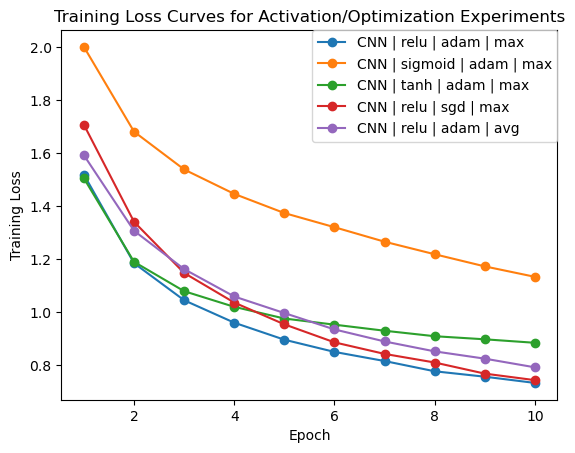

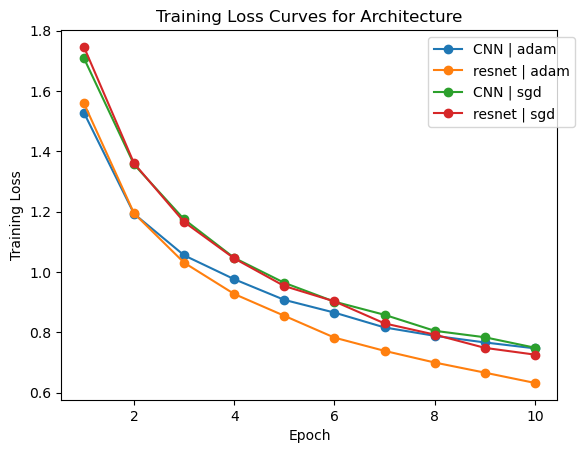

In [16]:
# Training Loss Curves
plt.figure()
for i, loss in enumerate(loss_exps[:-4]):
    plt.plot(range(1, len(loss)+1), loss, marker='o', label=exp1_names[i])

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves for Activation/Optimization Experiments')
plt.legend(loc='upper right', bbox_to_anchor=(1, 1), borderaxespad=0)
plt.savefig("train_loss1.png")
plt.show()
plt.figure()
for i, loss in enumerate(loss_exps[-4:]):
    plt.plot(range(1, len(loss)+1), loss, marker='o', label=exp2_names[i])

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves for Architecture')
plt.legend(bbox_to_anchor=(1.05, 1),loc = "upper right", borderaxespad=0.5)
plt.savefig("train_loss2.png")
plt.show()



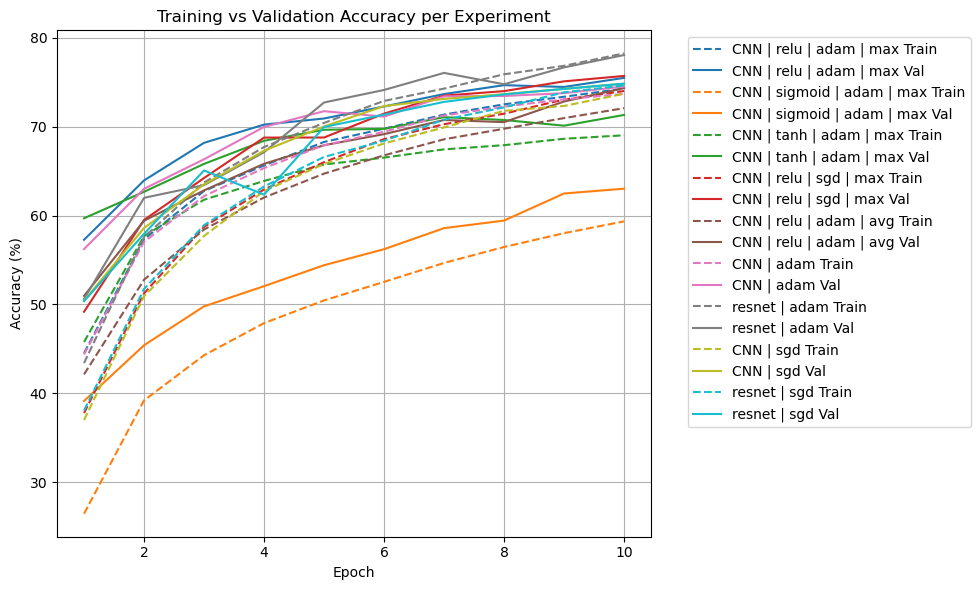

In [22]:
# Validation vs Training Accuracy
epochs = 10  # or whatever number of epochs you wanna run
# Get distinct colors
colors = cm.tab10(np.linspace(0, 1, len(exps)))  # tab10 has 10 colors

plt.figure(figsize=(10,6))

for i, exp in enumerate(exps):
    color = colors[i]
    # Dashed line for training
    plt.plot(range(1, epochs+1), train_acc[i], '--', color=color, label=f"{exp} Train")
    # Solid line for validation
    plt.plot(range(1, epochs+1), val_acc_total[i], '-', color=color, label=f"{exp} Val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy per Experiment")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("valid_train.png", dpi=300)
plt.show()

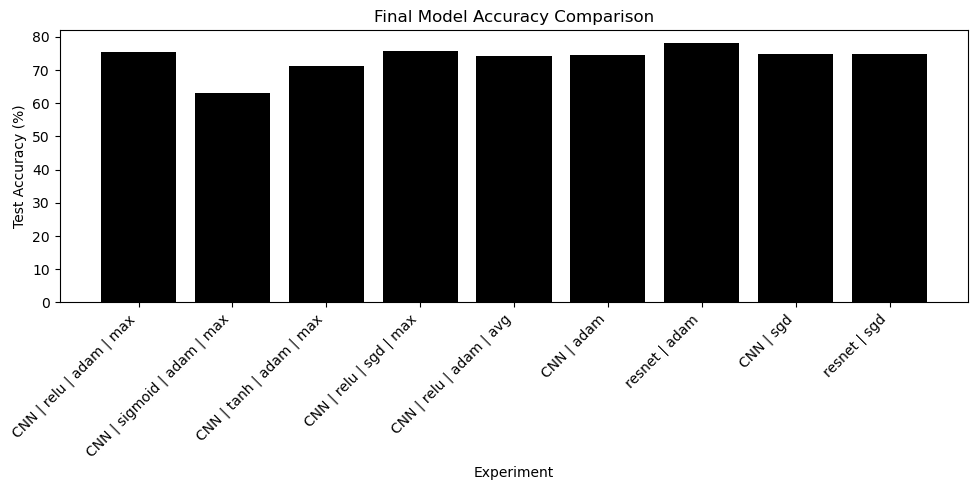

In [18]:
# Accuracy Comparison
plt.figure(figsize=(10,5))
plt.bar(exp1_names+exp2_names, acc_total, color = "black")

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Experiment")
plt.title("Final Model Accuracy Comparison")

plt.xticks(rotation=45, ha="right")  # rotate labels for readability
plt.tight_layout()
plt.savefig("acc_total.png")

plt.show()

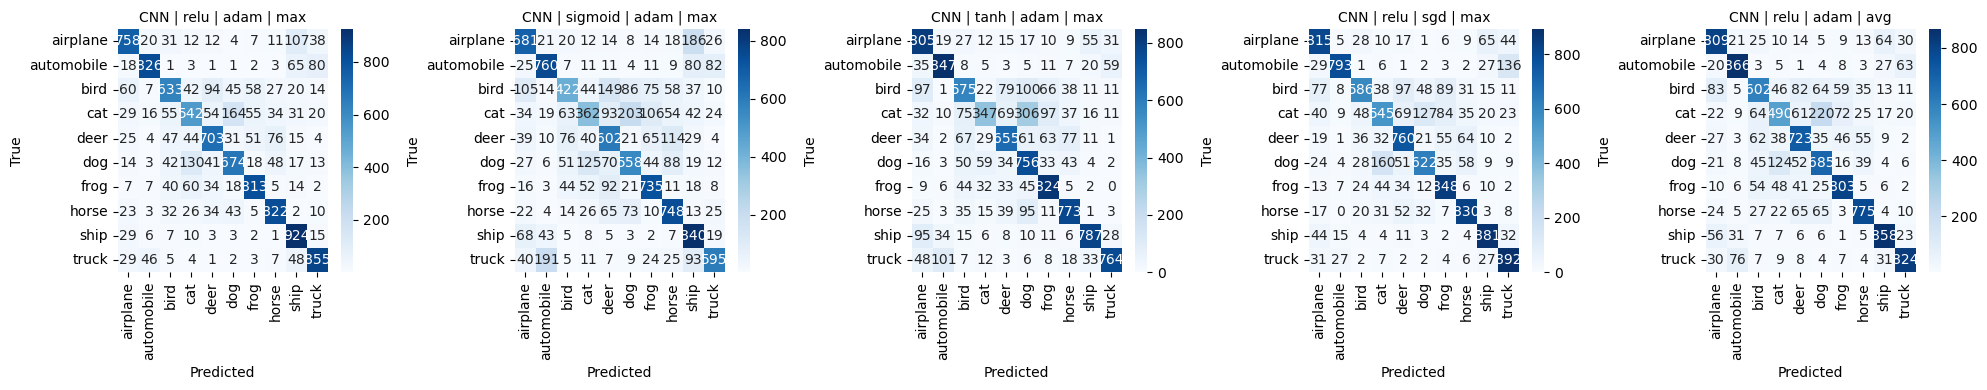

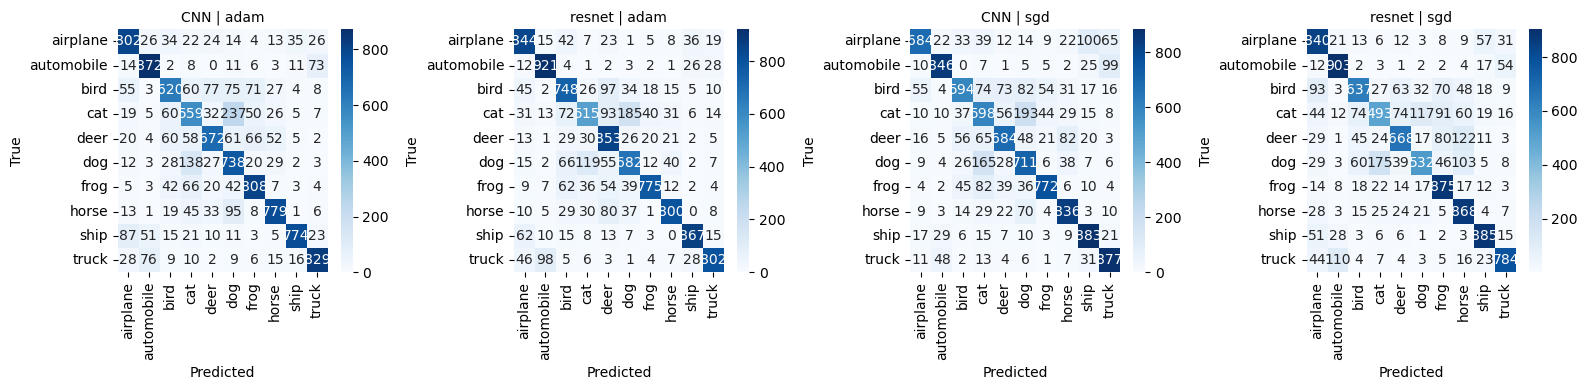

In [23]:
#Heatmap for Confusion Matrices
confusion_matrices = []
for i in range(len(exp_classes)):
    cm = confusion_matrix(exp_classes[i], exp_preds[i])
    confusion_matrices.append(cm)
classes_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
fig, axes = plt.subplots(1, 5, figsize=(20,4))  # 1 row, 5 columns
axes = axes.flatten()
#Just for this project, otherwise I would change the range to be flexible :{
for i in range(5):
    sns.heatmap(confusion_matrices[i], annot=True, fmt="d", cmap="Blues",
                xticklabels=classes_names, yticklabels=classes_names, ax=axes[i])
    axes[i].set_title(exps[i], fontsize=10)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrices_row1.png", dpi=300, bbox_inches="tight")
plt.show()
fig, axes = plt.subplots(1, 4, figsize=(16,4))  # 1 row, 4 columns
axes = axes.flatten()

for i in range(5, 9):
    sns.heatmap(confusion_matrices[i], annot=True, fmt="d", cmap="Blues",
                xticklabels=classes_names, yticklabels=classes_names, ax=axes[i-5])
    axes[i-5].set_title(exps[i], fontsize=10)
    axes[i-5].set_xlabel("Predicted")
    axes[i-5].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrices_row2.png", dpi=300, bbox_inches="tight")
plt.show()

Experiment 1: CNN | adam


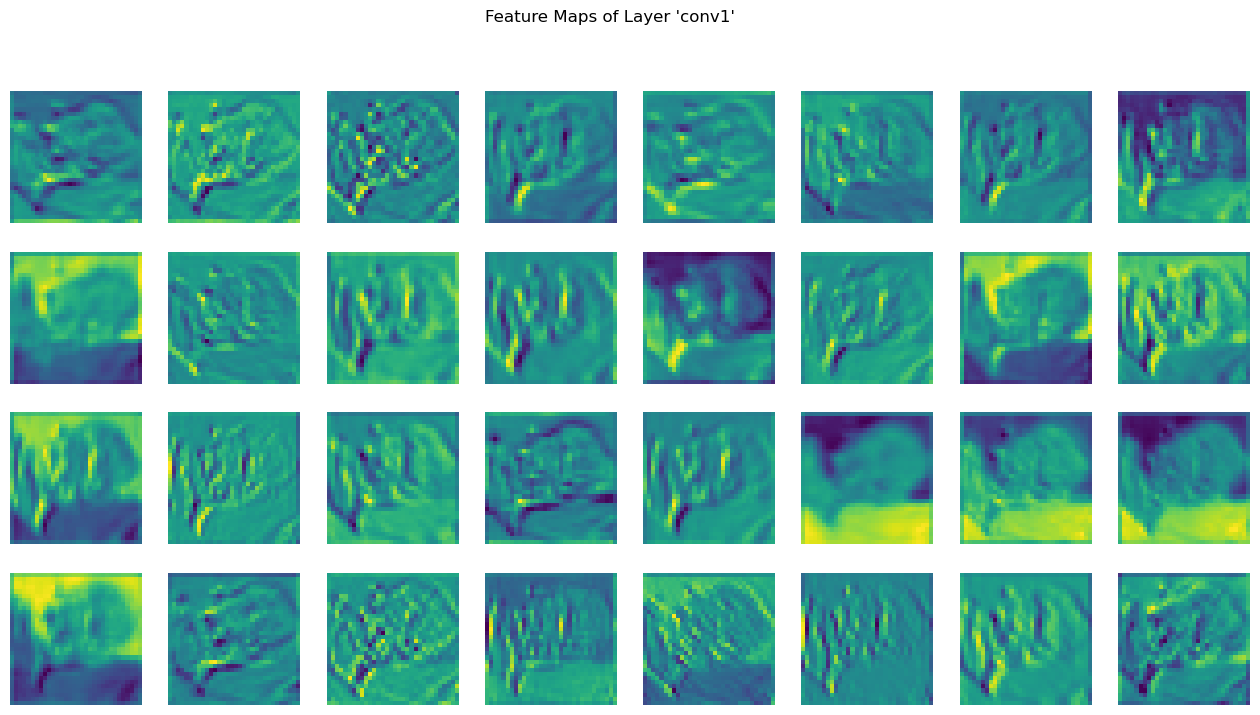

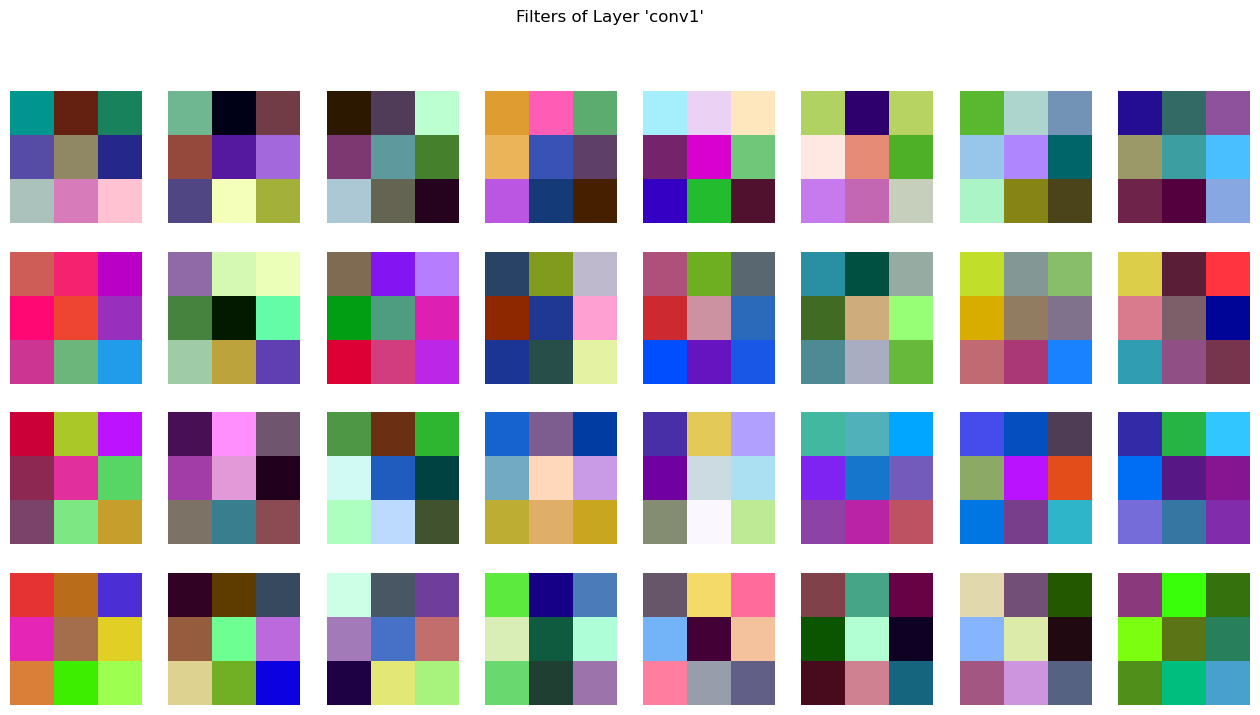

Experiment 2: resnet | adam


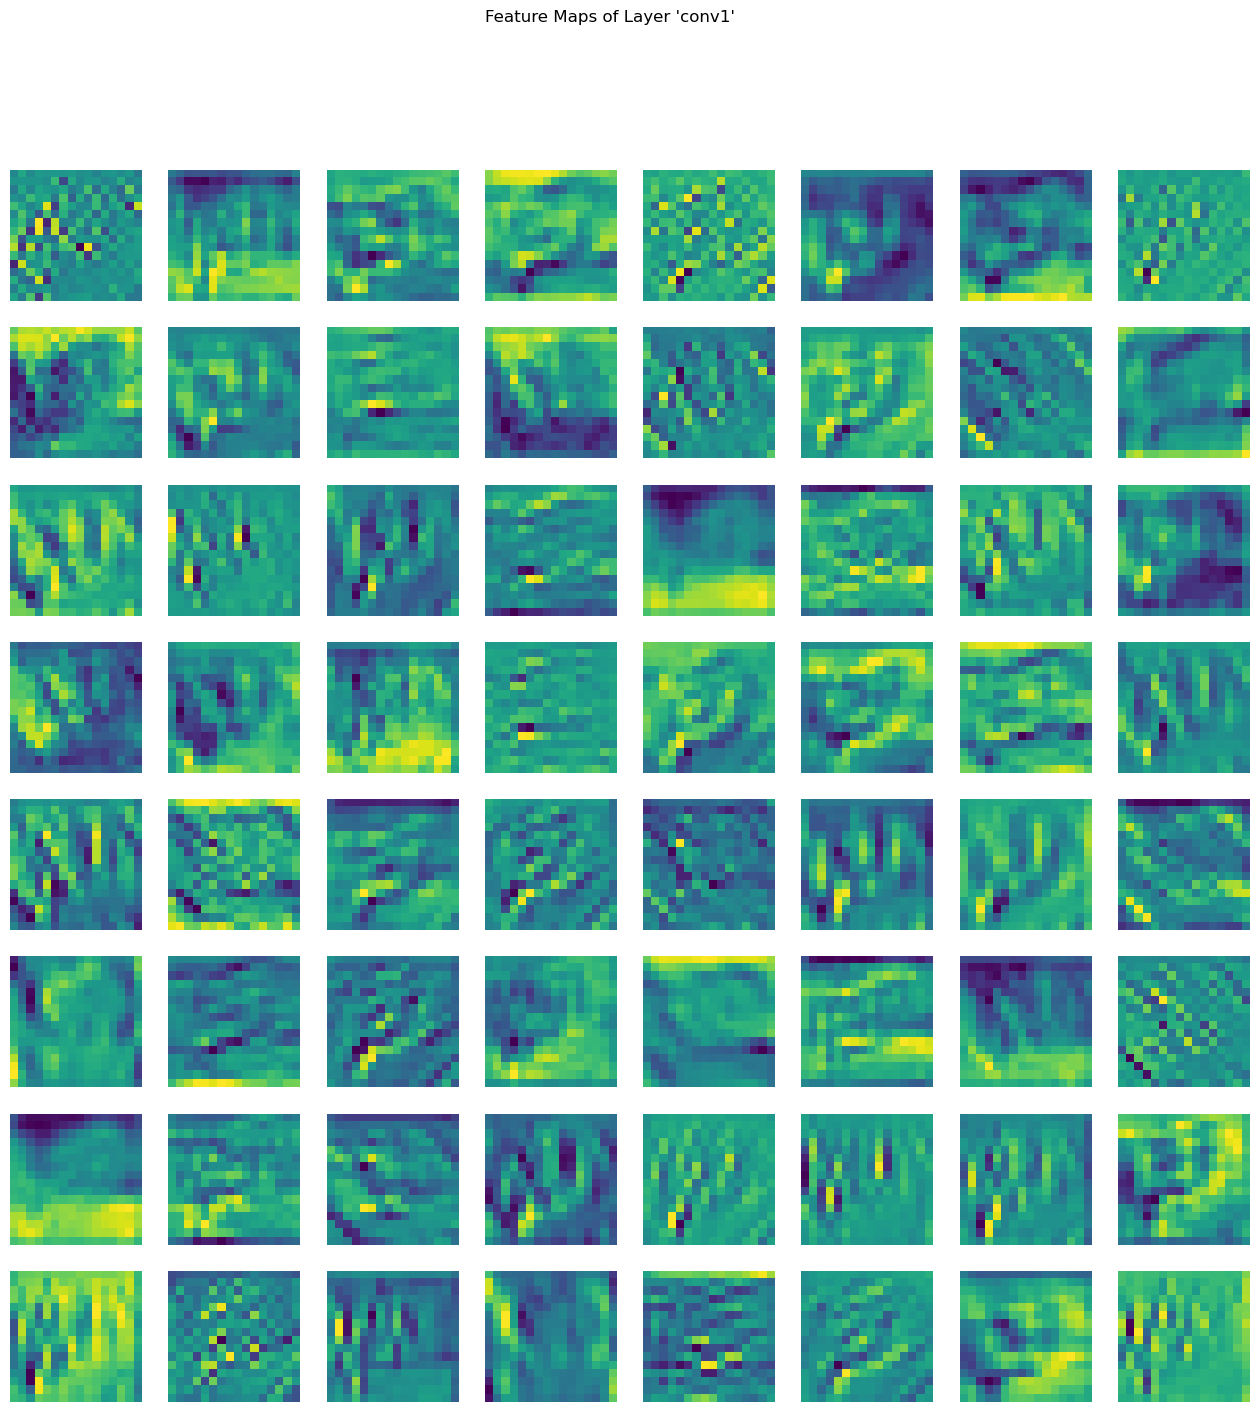

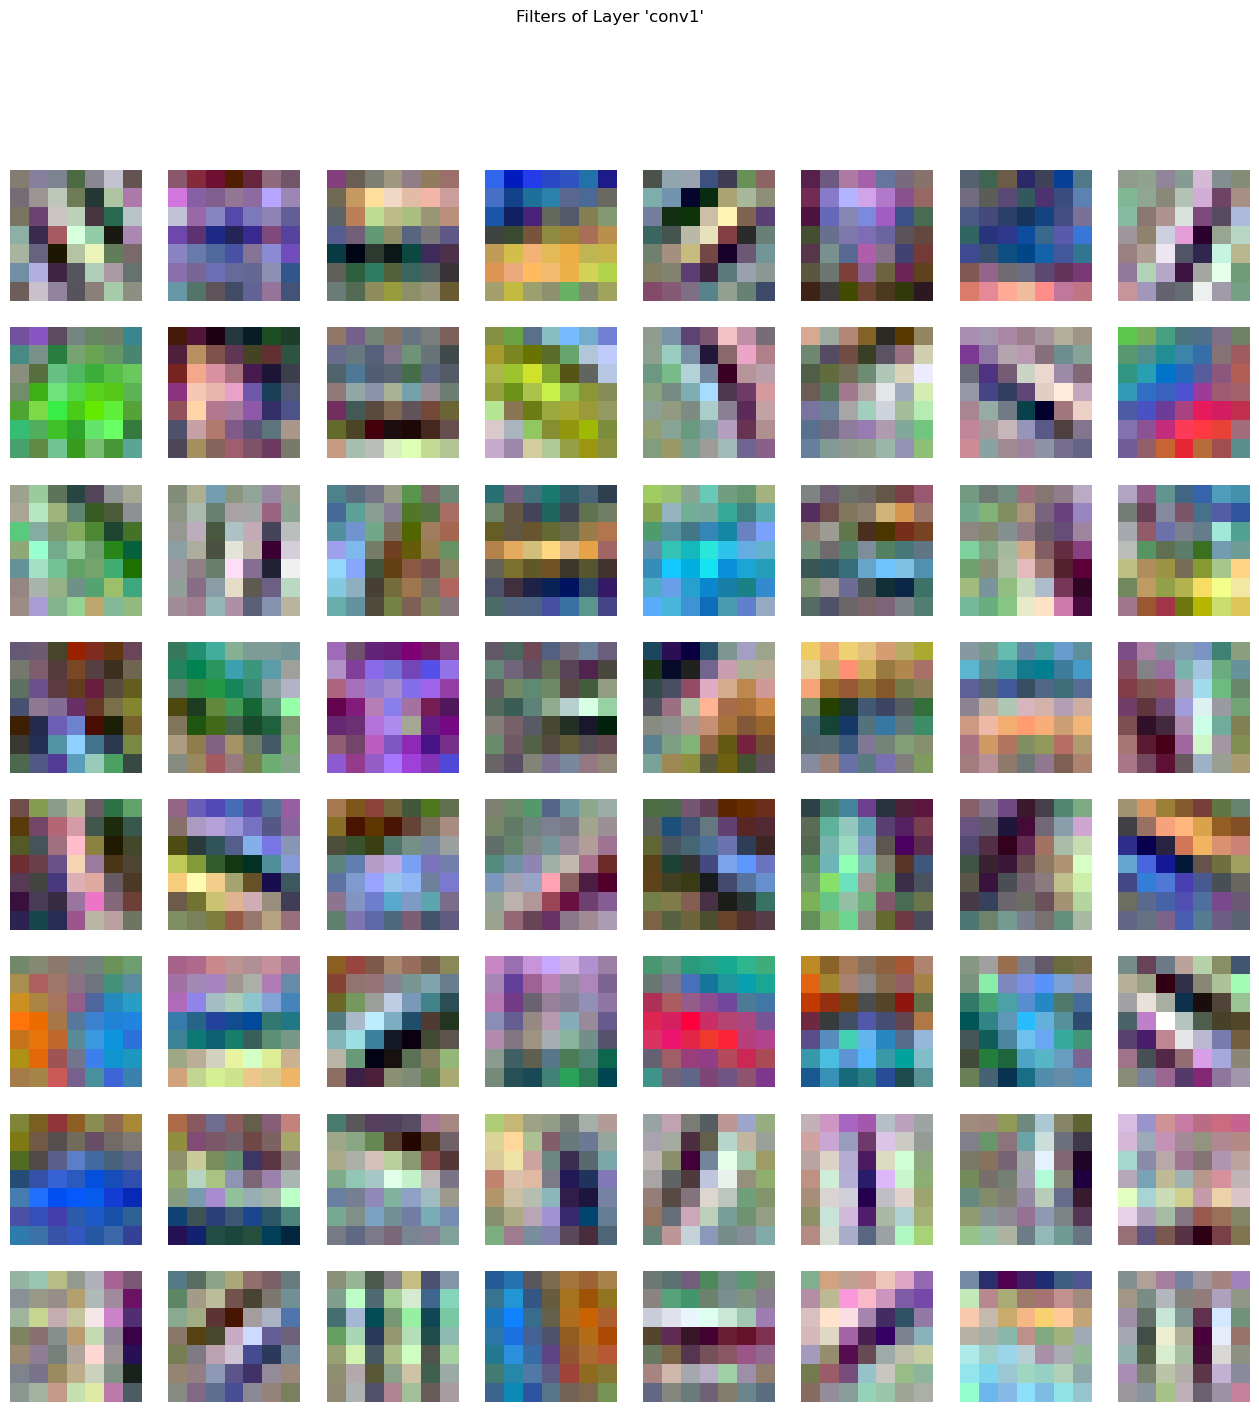

Experiment 3: CNN | sgd


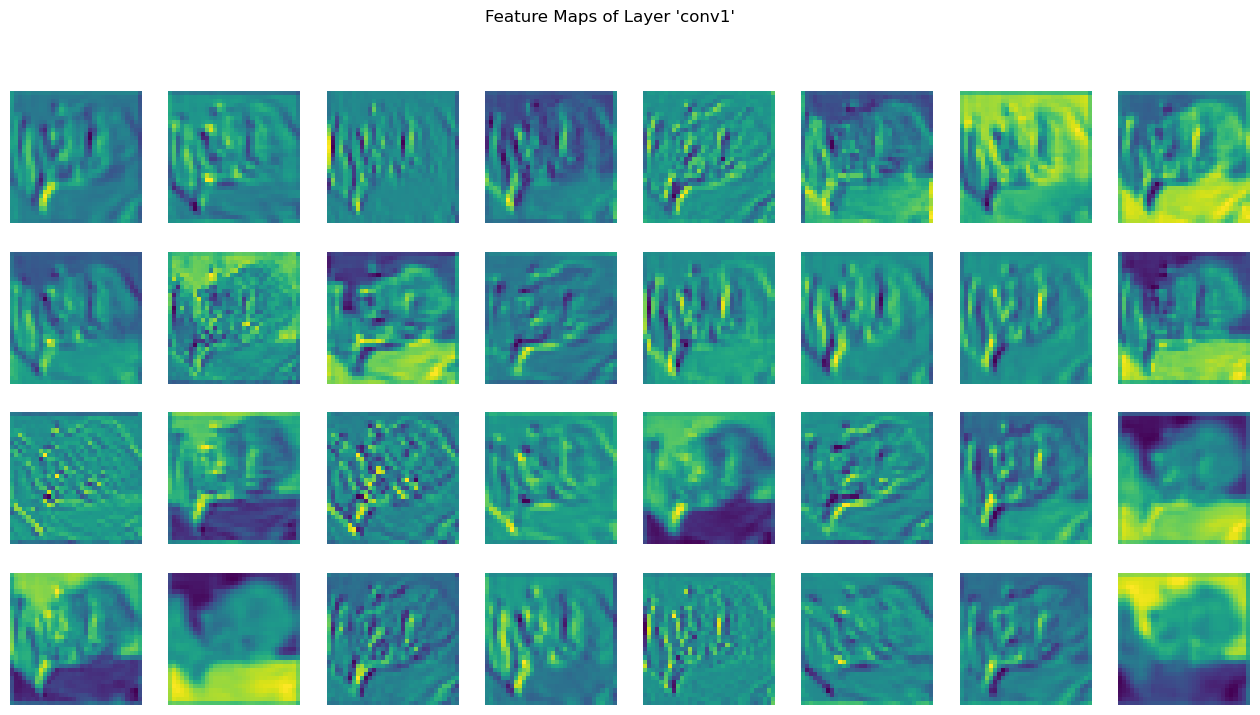

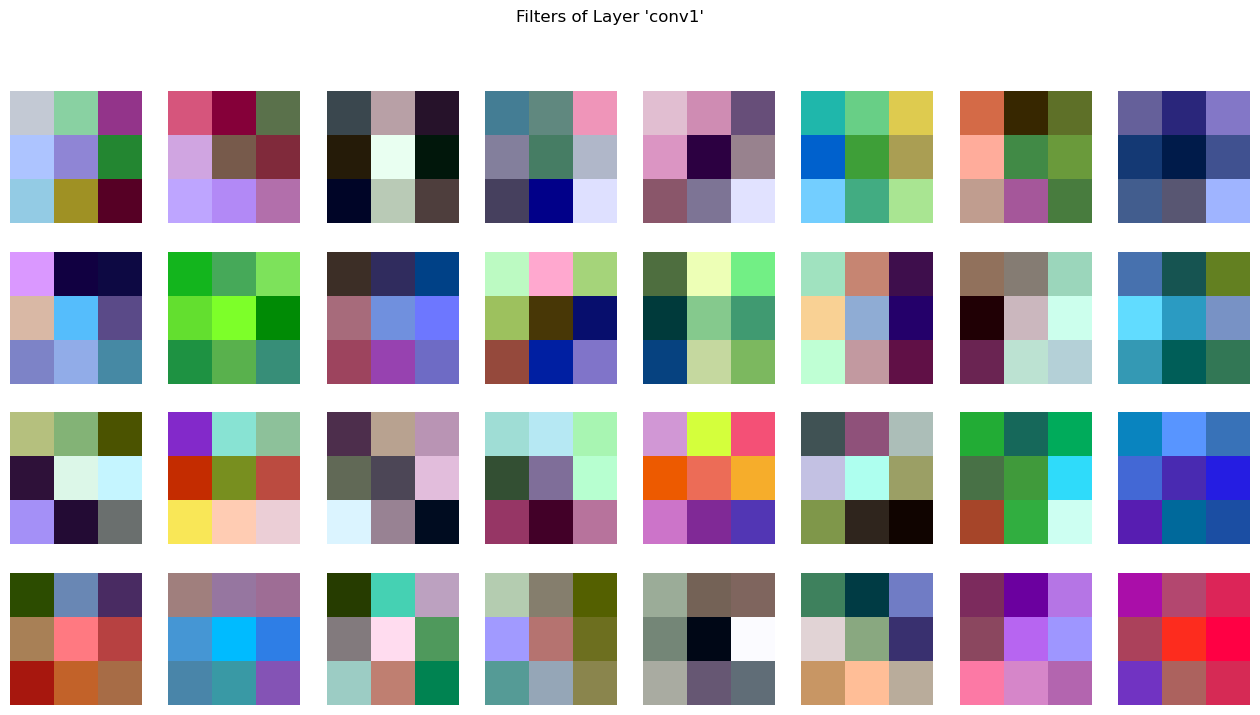

Experiment 4: resnet | sgd


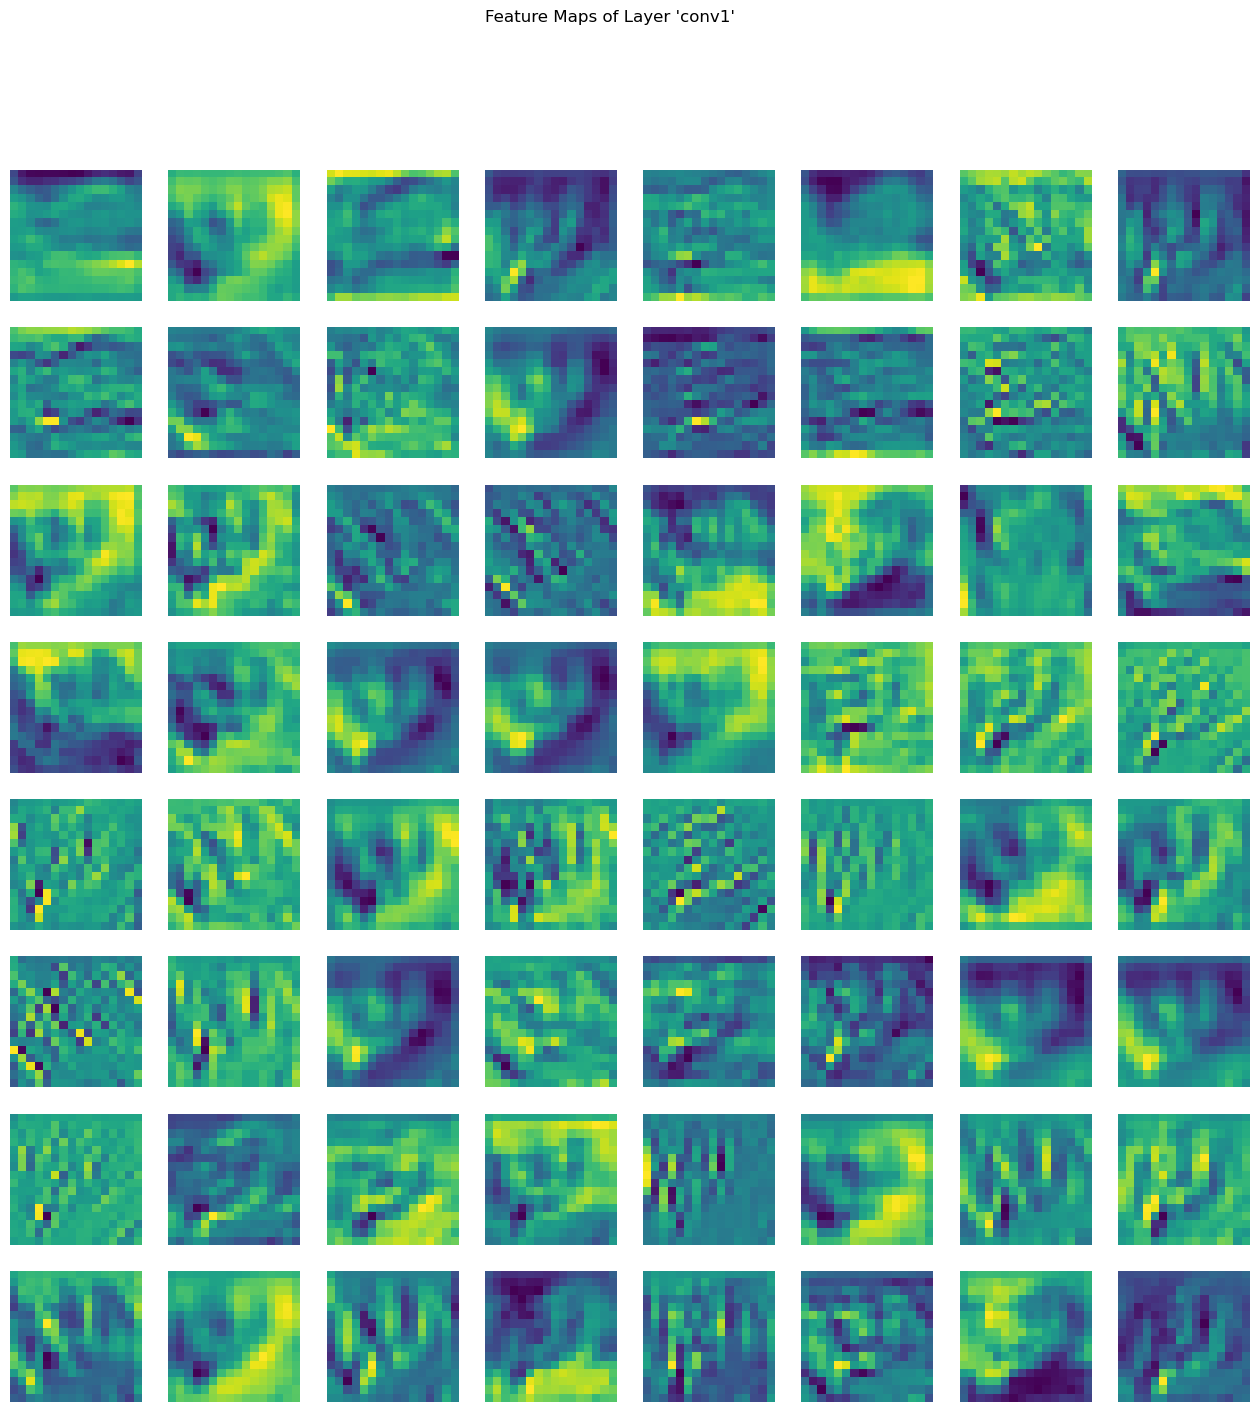

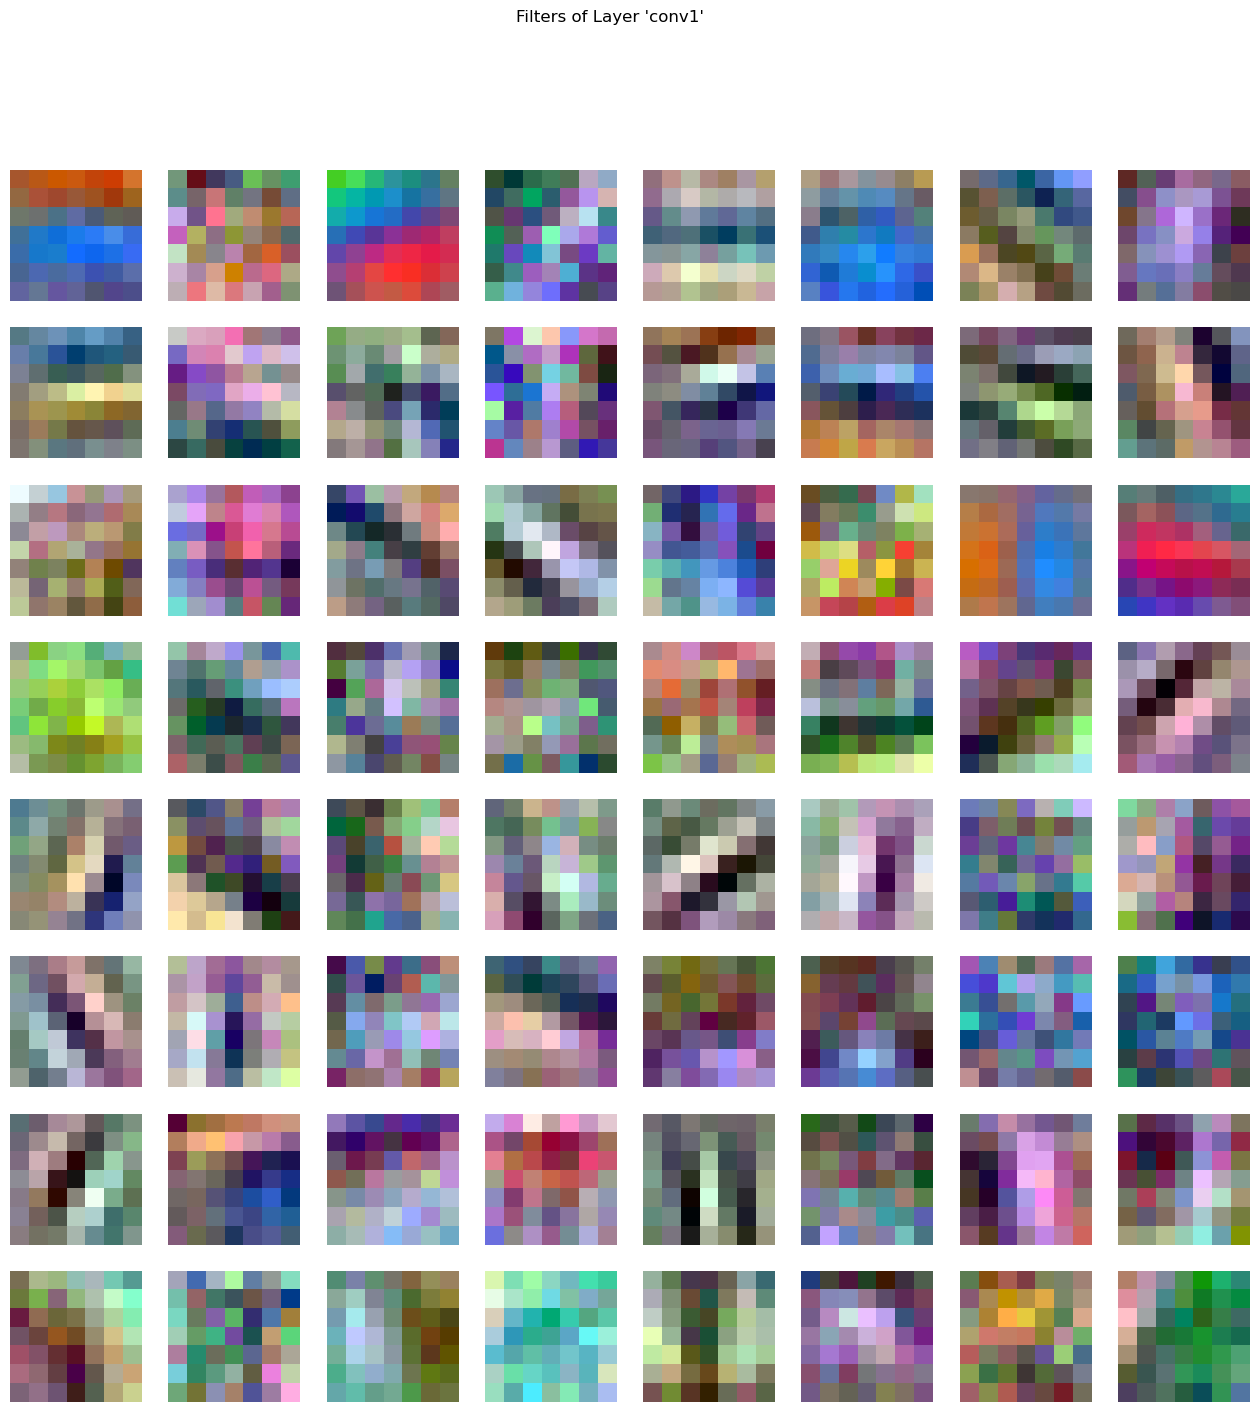

In [20]:
#Feature Mapping - purdy cool
for i, exp in enumerate(exp2_names):
    print(f"Experiment {i+1}: {exp}")
    vis_feat_map(exp_models[i], exp_testloaders[i], device, layer_name = "conv1", exp_name = exp)
